In [1]:
!pip install yfinance


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
stock = "GOOG"

start = "2013-01-01"
end = "2025-12-31"

data = yf.download(
    stock,
    start=start,
    end=end,
    auto_adjust=False
)

data.head()


[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,,
2013-01-02,17.844711,18.013729,18.107130,17.846855,17.918339,102033017
2013-01-03,17.855076,18.024191,18.229919,17.950716,18.055573,93075567
2013-01-04,18.207897,18.380356,18.467529,18.124067,18.165413,110954331
2013-01-07,18.128448,18.300158,18.415474,18.196297,18.317591,66476239
2013-01-08,18.092670,18.264042,18.338762,18.043119,18.319834,67295297


In [4]:
data = data[["Close"]]

data.head()

Price,Close
Ticker,GOOG
Date,
2013-01-02,18.013729
2013-01-03,18.024191
2013-01-04,18.380356
2013-01-07,18.300158
2013-01-08,18.264042


In [5]:
training_data_len = int(len(data) * 0.70)

print("Training data length:", training_data_len)


Training data length: 2288


In [6]:
train_data = data.iloc[:training_data_len].values

print(train_data.shape)


(2288, 1)


In [7]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

scaled_train_data = scaler.fit_transform(train_data)

print(scaled_train_data.shape)

(2288, 1)


In [8]:
x_train = []
y_train = []

for i in range(100, len(scaled_train_data)):
    x_train.append(scaled_train_data[i-100:i, 0])
    y_train.append(scaled_train_data[i, 0])

print("X:", len(x_train))
print("Y:", len(y_train))

X: 2188
Y: 2188


In [9]:
x_train = np.array(x_train)
y_train = np.array(y_train)

print("X shape:", x_train.shape)
print("Y shape:", y_train.shape)

X shape: (2188, 100)
Y shape: (2188,)


In [10]:
x_train = np.reshape(
    x_train,
    (x_train.shape[0], x_train.shape[1], 1)
)

print("Final X shape:", x_train.shape)
print("Final Y shape:", y_train.shape)

Final X shape: (2188, 100, 1)
Final Y shape: (2188,)


In [11]:
!pip install tensorflow

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM


In [17]:
model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(100, 1)
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(
        60,
        return_sequences=True
    )
)

model.add(Dropout(0.3))

model.add(
    LSTM(
        80,
        return_sequences=True
    )
)

model.add(Dropout(0.4))

model.add(
    LSTM(120)
)

model.add(Dropout(0.5))

model.add(Dense(1))

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 50)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 60)        │        26,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100, 60)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 80)        │        45,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 120)            │        96,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,761 (698.29 KB)

 Trainable params: 178,761 (698.29 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [16]:
import numpy as np

# Training sequences dobara banao
x_train = []
y_train = []

for i in range(100, len(scaled_train_data)):
    x_train.append(scaled_train_data[i-100:i, 0])
    y_train.append(scaled_train_data[i, 0])

# NumPy arrays
x_train = np.array(x_train)
y_train = np.array(y_train)

# LSTM ke liye 3D shape
x_train = np.reshape(
    x_train,
    (x_train.shape[0], x_train.shape[1], 1)
)

print("X shape:", x_train.shape)
print("Y shape:", y_train.shape)

X shape: (2188, 100, 1)
Y shape: (2188,)


In [19]:
model.compile(
    optimizer="adam",
    loss="mean_squared_error"
)

In [20]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32
)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 14s 115ms/step - loss: 0.0102
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - loss: 0.0032
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - loss: 0.0029
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - loss: 0.0023
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 7s 107ms/step - loss: 0.0024
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0026
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 112ms/step - loss: 0.0026
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0025
Epoch 9/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - loss: 0.0025
Epoch 10/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 114ms/step - loss: 0.0020
Epoch 11/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 122ms/step - loss: 0.0017
Epoch 12/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 121ms/step - loss: 0.0019
Epoch 13/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 9s 129ms/step - loss: 0.0017
Epoch 14/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - loss: 0.0019
Epoch 15/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - l

In [21]:
test_data = data.iloc[training_data_len-100:].values

print("Test data shape:", test_data.shape)

Test data shape: (1081, 1)


In [22]:
scaled_test_data = scaler.transform(test_data)

print("Scaled test data shape:", scaled_test_data.shape)

Scaled test data shape: (1081, 1)


In [23]:
x_test = []

for i in range(100, len(scaled_test_data)):
    x_test.append(scaled_test_data[i-100:i, 0])

x_test = np.array(x_test)

print("X test shape:", x_test.shape)

X test shape: (981, 100)


In [24]:
x_test = np.reshape(
    x_test,
    (x_test.shape[0], x_test.shape[1], 1)
)

print("Final X test shape:", x_test.shape)

Final X test shape: (981, 100, 1)


In [28]:
y_test = data.iloc[training_data_len:].values

print("Y test shape:", y_test.shape)

Y test shape: (981, 1)


In [29]:
predictions = model.predict(x_test)

print("Prediction shape:", predictions.shape)

31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step
Prediction shape: (981, 1)


In [30]:
predictions = scaler.inverse_transform(predictions)

print("First 5 predictions:")
print(predictions[:5])

First 5 predictions:
[[133.46469]
 [133.99904]
 [134.91885]
 [135.99477]
 [136.9592 ]]


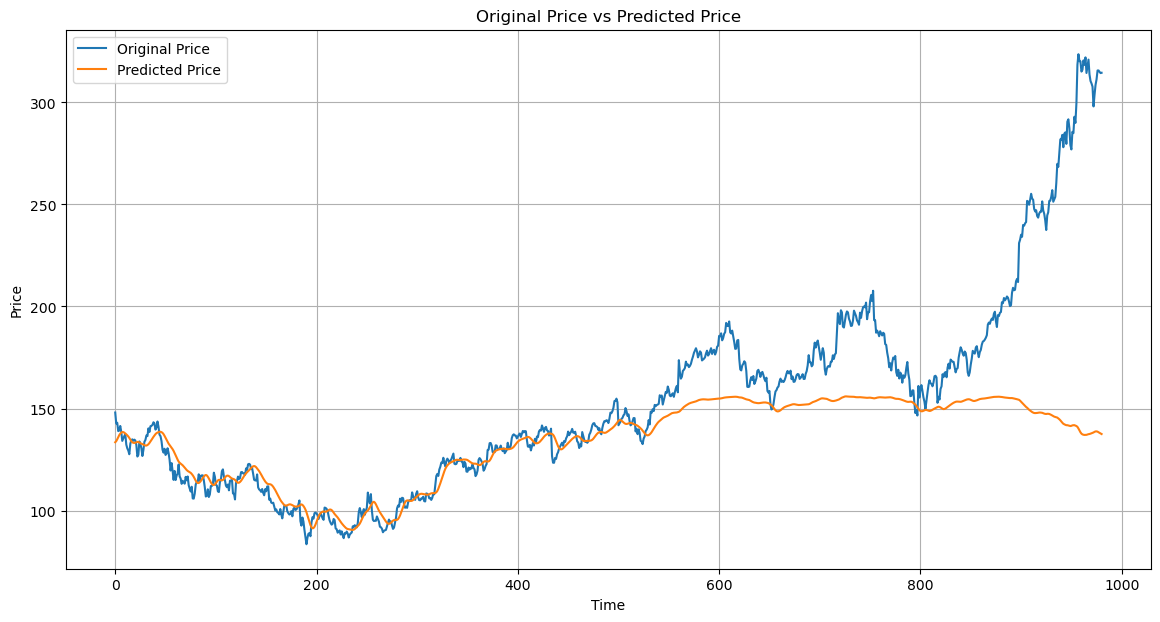

In [31]:
plt.figure(figsize=(14, 7))

plt.plot(
    y_test,
    label="Original Price"
)

plt.plot(
    predictions,
    label="Predicted Price"
)

plt.title("Original Price vs Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

In [32]:
model.save("Stock Predictions Model.keras")

print("Model saved successfully!")

Model saved successfully!


In [33]:
print("Model training completed successfully.")
print("Model file: Stock Predictions Model.keras")
print("Total test samples:", len(y_test))
print("Total predictions:", len(predictions))

Model training completed successfully.
Model file: Stock Predictions Model.keras
Total test samples: 981
Total predictions: 981


In [34]:
!pip install streamlit

  Attempting uninstall: protobuf
    Found existing installation: protobuf 7.36.1
    Uninstalling protobuf-7.36.1:
      Successfully uninstalled protobuf-7.36.1


  You can safely remove it manually.


In [35]:
%%writefile app.py

import streamlit as st
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import load_model


st.title("📈 Stock Price Prediction")
st.write("LSTM Based Stock Price Prediction")


stock = st.text_input(
    "Enter Stock Symbol",
    "GOOG"
)


if st.button("Predict"):

    data = yf.download(
        stock,
        start="2013-01-01",
        end="2025-12-31",
        auto_adjust=False
    )

    if data.empty:
        st.error("Invalid stock symbol or no data found.")
    else:

        data = data[["Close"]]

        scaler = MinMaxScaler(feature_range=(0, 1))

        training_data_len = int(len(data) * 0.70)

        train_data = data.iloc[:training_data_len].values

        scaler.fit(train_data)

        test_data = data.iloc[training_data_len-100:].values

        scaled_test_data = scaler.transform(test_data)

        x_test = []

        for i in range(100, len(scaled_test_data)):
            x_test.append(
                scaled_test_data[i-100:i, 0]
            )

        x_test = np.array(x_test)

        x_test = np.reshape(
            x_test,
            (x_test.shape[0], x_test.shape[1], 1)
        )

        model = load_model(
            "Stock Predictions Model.keras"
        )

        predictions = model.predict(
            x_test,
            verbose=0
        )

        predictions = scaler.inverse_transform(
            predictions
        )

        y_test = data.iloc[training_data_len:].values

        st.subheader("Original Price vs Predicted Price")

        fig, ax = plt.subplots(figsize=(14, 7))

        ax.plot(
            y_test,
            label="Original Price"
        )

        ax.plot(
            predictions,
            label="Predicted Price"
        )

        ax.set_xlabel("Time")
        ax.set_ylabel("Price")
        ax.legend()
        ax.grid(True)

        st.pyplot(fig)

        st.success("Prediction completed successfully!")

Writing app.py


In [1]:
%%writefile requirements.txt

streamlit
numpy
pandas
matplotlib
scikit-learn
yfinance
tensorflow

Writing requirements.txt


In [2]:
%%writefile README.md

# 📈 Stock Price Prediction using LSTM

An end-to-end Machine Learning project that predicts stock prices using a Long Short-Term Memory (LSTM) neural network and provides an interactive Streamlit web application.

## 🚀 Project Overview

This project uses historical stock market data to train an LSTM-based deep learning model.

The model learns patterns from the previous **100 days of stock prices** and generates predictions for subsequent observations.

The trained model is integrated into a **Streamlit web application** where users can enter a stock symbol and visualize the original and predicted prices.

## 🧠 Machine Learning Workflow

1. Collect historical stock data using Yahoo Finance
2. Select closing price data
3. Split data into training and testing sets
4. Scale prices using Min-Max Scaling
5. Create 100-day time-series sequences
6. Train an LSTM neural network
7. Generate predictions on test data
8. Convert predictions back to the original price scale
9. Visualize original vs predicted prices
10. Deploy the model using Streamlit

## 🛠️ Technologies Used

- Python
- NumPy
- Pandas
- Matplotlib
- Scikit-learn
- TensorFlow / Keras
- LSTM
- yFinance
- Streamlit

## 📂 Project Structure

```text
Stock-Price-Prediction/
│
├── app.py
├── Stock Predictions Model.keras
├── requirements.txt
└── README.md

Writing README.md


In [3]:
import os

print("Folder:")
print(os.getcwd())

print("\nFiles:")
for file in os.listdir():
    print(file)

Folder:
C:\Users\Akshra

Files:
-1.14-windows.xml
.anaconda
.android
.conda
.continuum
.copilot
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.keras
.matplotlib
.spyder-py3
.streamlit
.vscode
.vscode-shared
anaconda3
app.py
AppData
Application Data
Contacts
Cookies
CrossDevice
Documents
donation.html
Downloads
Favorites
Links
Local Settings
Music
My Documents
NetHood
NTUSER.DAT
ntuser.dat.LOG1
ntuser.dat.LOG2
NTUSER.DAT{11347699-2ec2-11f0-9fda-9010579c715f}.TM.blf
NTUSER.DAT{11347699-2ec2-11f0-9fda-9010579c715f}.TM.blf.cnpf
NTUSER.DAT{11347699-2ec2-11f0-9fda-9010579c715f}.TMContainer00000000000000000001.regtrans-ms
NTUSER.DAT{11347699-2ec2-11f0-9fda-9010579c715f}.TMContainer00000000000000000001.regtrans-ms.cnpf
NTUSER.DAT{11347699-2ec2-11f0-9fda-9010579c715f}.TMContainer00000000000000000002.regtrans-ms
NTUSER.DAT{11347699-2ec2-11f0-9fda-9010579c715f}.TMContainer00000000000000000002.regtrans-ms.cnpf
ntuser.ini
OneDrive
Pictures
practice.py
PrintHood
README.md
Recent
requirements.txt
Save